In [3]:
!pip install scikit-fuzzy

import skfuzzy as fuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.0 MB/s eta 0:00:00


## Fuzzy Logic
- Fuzzy Logic Rule Base for 3D Printing Parameter Optimization.
- Research: Fuzzy Set Theory Applications in 3D Printing for Improved Mechanical Properties


## Step-1:- Import all the library

In [7]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## Step-2:- Define Input and Output Variable


In [8]:
temperature    = ctrl.Antecedent(np.arange(170, 241, 1), 'Temperature')   # °C
printing_speed = ctrl.Antecedent(np.arange(20,  101, 1), 'Printing_Speed') # mm/s
layer_thickness= ctrl.Antecedent(np.arange(0.1, 0.41, 0.01), 'Layer_Thickness') # mm
tensile_strength = ctrl.Consequent(np.arange(0, 101, 1), 'Tensile_Strength')    # MPa (normalised 0–100)

## **Step-3**:- MEMBERSHIP FUNCTIONS (Triangular)

In [12]:
# Nozzle Temperature (°C)
temperature['Low']    = fuzz.trimf(temperature.universe,    [170, 170, 205])
temperature['Medium'] = fuzz.trimf(temperature.universe,    [190, 205, 225])
temperature['High']   = fuzz.trimf(temperature.universe,    [210, 240, 240])

# Printing Speed (mm/s)
printing_speed['Low']    = fuzz.trimf(printing_speed.universe, [20,  20,  55])
printing_speed['Medium'] = fuzz.trimf(printing_speed.universe, [40,  60,  80])
printing_speed['High']   = fuzz.trimf(printing_speed.universe, [65, 100, 100])

# Layer Thickness (mm)
layer_thickness['Low']    = fuzz.trimf(layer_thickness.universe, [0.10, 0.10, 0.22])
layer_thickness['Medium'] = fuzz.trimf(layer_thickness.universe, [0.18, 0.25, 0.32])
layer_thickness['High']   = fuzz.trimf(layer_thickness.universe, [0.28, 0.40, 0.40])

# Tensile Strength Output
tensile_strength['Poor']     = fuzz.trimf(tensile_strength.universe, [0,   0,  40])
tensile_strength['Moderate'] = fuzz.trimf(tensile_strength.universe, [30,  50,  70])
tensile_strength['Good']     = fuzz.trimf(tensile_strength.universe, [60, 100, 100])


## Step4:-FUZZY RULE BASE (27 Rules — Full Coverage)

In [13]:

rules = [
    # ── High Temperature ──────────────────────────────────────────────
    ctrl.Rule(temperature['High'] & printing_speed['Low']    & layer_thickness['Low'],    tensile_strength['Good']),     # R1
    ctrl.Rule(temperature['High'] & printing_speed['Low']    & layer_thickness['Medium'], tensile_strength['Good']),     # R2
    ctrl.Rule(temperature['High'] & printing_speed['Low']    & layer_thickness['High'],   tensile_strength['Moderate']), # R3
    ctrl.Rule(temperature['High'] & printing_speed['Medium'] & layer_thickness['Low'],    tensile_strength['Good']),     # R4
    ctrl.Rule(temperature['High'] & printing_speed['Medium'] & layer_thickness['Medium'], tensile_strength['Moderate']), # R5
    ctrl.Rule(temperature['High'] & printing_speed['Medium'] & layer_thickness['High'],   tensile_strength['Moderate']), # R6
    ctrl.Rule(temperature['High'] & printing_speed['High']   & layer_thickness['Low'],    tensile_strength['Moderate']), # R7
    ctrl.Rule(temperature['High'] & printing_speed['High']   & layer_thickness['Medium'], tensile_strength['Moderate']), # R8
    ctrl.Rule(temperature['High'] & printing_speed['High']   & layer_thickness['High'],   tensile_strength['Poor']),     # R9

    # ── Medium Temperature ────────────────────────────────────────────
    ctrl.Rule(temperature['Medium'] & printing_speed['Low']    & layer_thickness['Low'],    tensile_strength['Good']),     # R10
    ctrl.Rule(temperature['Medium'] & printing_speed['Low']    & layer_thickness['Medium'], tensile_strength['Moderate']), # R11
    ctrl.Rule(temperature['Medium'] & printing_speed['Low']    & layer_thickness['High'],   tensile_strength['Moderate']), # R12
    ctrl.Rule(temperature['Medium'] & printing_speed['Medium'] & layer_thickness['Low'],    tensile_strength['Moderate']), # R13
    ctrl.Rule(temperature['Medium'] & printing_speed['Medium'] & layer_thickness['Medium'], tensile_strength['Moderate']), # R14
    ctrl.Rule(temperature['Medium'] & printing_speed['Medium'] & layer_thickness['High'],   tensile_strength['Moderate']), # R15
    ctrl.Rule(temperature['Medium'] & printing_speed['High']   & layer_thickness['Low'],    tensile_strength['Moderate']), # R16
    ctrl.Rule(temperature['Medium'] & printing_speed['High']   & layer_thickness['Medium'], tensile_strength['Poor']),     # R17
    ctrl.Rule(temperature['Medium'] & printing_speed['High']   & layer_thickness['High'],   tensile_strength['Poor']),     # R18

    # ── Low Temperature ───────────────────────────────────────────────
    ctrl.Rule(temperature['Low'] & printing_speed['Low']    & layer_thickness['Low'],    tensile_strength['Moderate']), # R19
    ctrl.Rule(temperature['Low'] & printing_speed['Low']    & layer_thickness['Medium'], tensile_strength['Poor']),     # R20
    ctrl.Rule(temperature['Low'] & printing_speed['Low']    & layer_thickness['High'],   tensile_strength['Poor']),     # R21
    ctrl.Rule(temperature['Low'] & printing_speed['Medium'] & layer_thickness['Low'],    tensile_strength['Poor']),     # R22
    ctrl.Rule(temperature['Low'] & printing_speed['Medium'] & layer_thickness['Medium'], tensile_strength['Poor']),     # R23
    ctrl.Rule(temperature['Low'] & printing_speed['Medium'] & layer_thickness['High'],   tensile_strength['Poor']),     # R24
    ctrl.Rule(temperature['Low'] & printing_speed['High']   & layer_thickness['Low'],    tensile_strength['Poor']),     # R25
    ctrl.Rule(temperature['Low'] & printing_speed['High']   & layer_thickness['Medium'], tensile_strength['Poor']),     # R26
    ctrl.Rule(temperature['Low'] & printing_speed['High']   & layer_thickness['High'],   tensile_strength['Poor']),     # R27
]


## Step5:- BUILD & SIMULATE FUZZY CONTROL SYSTEM

In [14]:
printing_ctrl = ctrl.ControlSystem(rules)
printing_sim  = ctrl.ControlSystemSimulation(printing_ctrl)

# Example: Test with optimal parameters
printing_sim.input['Temperature']     = 230   # High
printing_sim.input['Printing_Speed']  = 30    # Low
printing_sim.input['Layer_Thickness'] = 0.15  # Low

printing_sim.compute()
result = printing_sim.output['Tensile_Strength']
print(f"\n{'='*50}")
print(f"  INPUT PARAMETERS:")
print(f"    Nozzle Temperature : 230 °C  (High)")
print(f"    Printing Speed     : 30 mm/s (Low)")
print(f"    Layer Thickness    : 0.15 mm (Low)")
print(f"  PREDICTED OUTPUT:")
print(f"    Tensile Strength   : {result:.2f} / 100  → GOOD")
print(f"{'='*50}\n")



  INPUT PARAMETERS:
    Nozzle Temperature : 230 °C  (High)
    Printing Speed     : 30 mm/s (Low)
    Layer Thickness    : 0.15 mm (Low)
  PREDICTED OUTPUT:
    Tensile Strength   : 85.03 / 100  → GOOD



## Step:- Plot Membership function


(-0.05, 1.1)

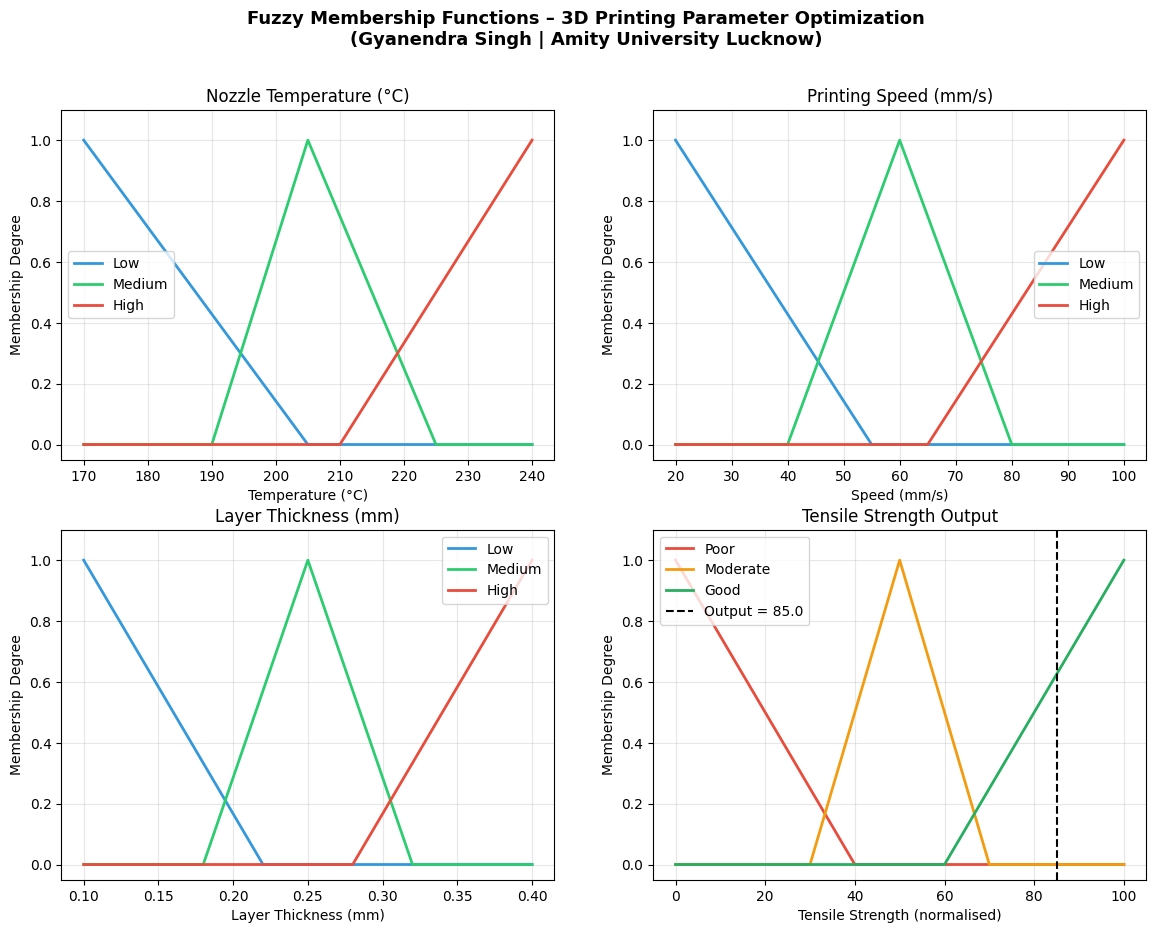

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fuzzy Membership Functions – 3D Printing Parameter Optimization\n(Gyanendra Singh | Amity University Lucknow)',
             fontsize=13, fontweight='bold')

colors = {'Low': '#3498db', 'Medium': '#2ecc71', 'High': '#e74c3c',
          'Poor': '#e74c3c', 'Moderate': '#f39c12', 'Good': '#27ae60'}


# Temperature
ax = axes[0, 0]
for label in ['Low', 'Medium', 'High']:
    ax.plot(temperature.universe, fuzz.trimf(temperature.universe,
            [170,170,205] if label=='Low' else [190,205,225] if label=='Medium' else [210,240,240]),
            label=label, color=colors[label], linewidth=2)
ax.set_title('Nozzle Temperature (°C)'); ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Membership Degree')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([-0.05, 1.1])

# Printing Speed
ax = axes[0, 1]
for label in ['Low', 'Medium', 'High']:
    ax.plot(printing_speed.universe, fuzz.trimf(printing_speed.universe,
            [20,20,55] if label=='Low' else [40,60,80] if label=='Medium' else [65,100,100]),
            label=label, color=colors[label], linewidth=2)
ax.set_title('Printing Speed (mm/s)'); ax.set_xlabel('Speed (mm/s)'); ax.set_ylabel('Membership Degree')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([-0.05, 1.1])

# Layer Thickness
ax = axes[1, 0]
for label in ['Low', 'Medium', 'High']:
    ax.plot(layer_thickness.universe, fuzz.trimf(layer_thickness.universe,
            [0.10,0.10,0.22] if label=='Low' else [0.18,0.25,0.32] if label=='Medium' else [0.28,0.40,0.40]),
            label=label, color=colors[label], linewidth=2)
ax.set_title('Layer Thickness (mm)'); ax.set_xlabel('Layer Thickness (mm)'); ax.set_ylabel('Membership Degree')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([-0.05, 1.1])

# Tensile Strength Output
ax = axes[1, 1]
for label in ['Poor', 'Moderate', 'Good']:
    ax.plot(tensile_strength.universe, fuzz.trimf(tensile_strength.universe,
            [0,0,40] if label=='Poor' else [30,50,70] if label=='Moderate' else [60,100,100]),
            label=label, color=colors[label], linewidth=2)
ax.axvline(x=result, color='black', linestyle='--', linewidth=1.5, label=f'Output = {result:.1f}')
ax.set_title('Tensile Strength Output'); ax.set_xlabel('Tensile Strength (normalised)'); ax.set_ylabel('Membership Degree')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim([-0.05, 1.1])
